In [ ]:
# THỰC HÀNH 4: PHÂN VÙNG ẢNH

## 1. Cài đặt thư viện

In [5]:
pip install opencv-python

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Viết chương trình phân vùng ảnh

### 2.1 Phân vùng theo Histogram

#### 2.1.1 Phương pháp Otsu

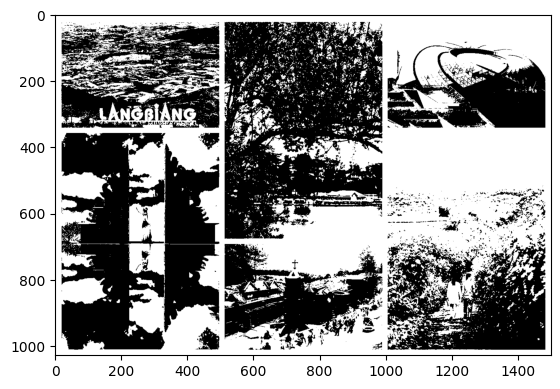

In [3]:
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
import matplotlib.pylab as plt
from skimage.filters.thresholding import threshold_otsu
data = Image.open('exercise/dalat.jpg').convert('L')
a = np.asarray(data)
# performing Otsu's thresholding
thres = threshold_otsu (a)
# pixels with intensity greater than theshold are kept
b = a > thres
b = Image.fromarray (b)
plt.imshow(b)
plt.show()

#### 2.1.2 Phương pháp Adaptive Thresholding

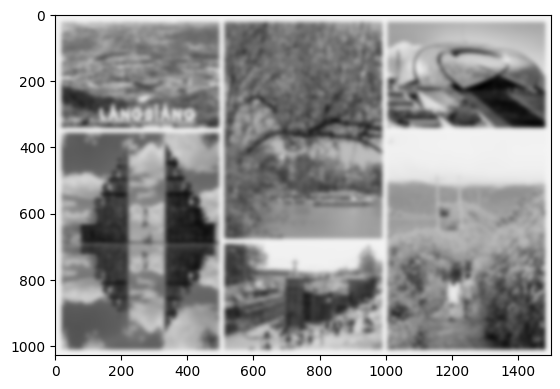

In [ ]:
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
import matplotlib.pylab as plt
from skimage.filters import threshold_local
data = Image.open('exercise/dalat.jpg').convert('L')
a = np.asarray (data)
b = threshold_local (a, 39, offset=10)
b = Image.fromarray(b)
plt.imshow (b)
plt.show ()


### 2.2 Phân vùng theo region

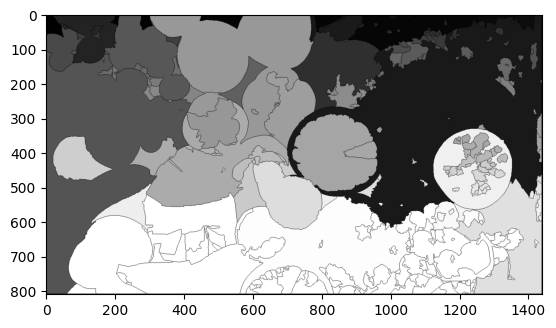

In [ ]:
import cv2
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
from scipy.ndimage import label
import matplotlib.pylab as plt
from skimage.filters import threshold_local
data = cv2.imread('fruit.jpg')
a = cv2.cvtColor (data, cv2.COLOR_BGR2GRAY)
thresh, b1 = cv2.threshold(a, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
b2 = cv2.erode (b1, None, iterations = 2)
dist_trans = cv2.distanceTransform (b2, 2, 3)
thresh, dt = cv2.threshold (dist_trans, 1, 255, cv2.THRESH_BINARY)
labelled, ncc = label (dt)
labelled = labelled.astype (np.int32)
cv2.watershed(data, labelled)
b = Image.fromarray (labelled)
plt.imshow (b)
plt.show ()


### 2.3 Biến đổi đối tượng trong ảnh

#### 2.3.1 Sử dụng binary_dilation

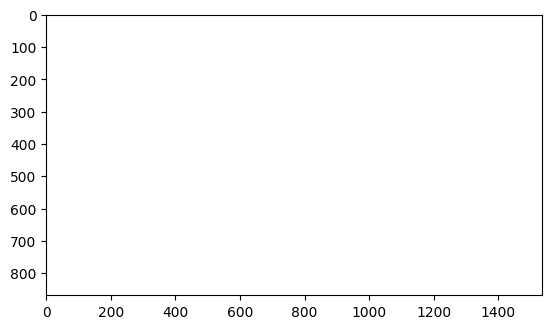

In [ ]:
import cv2
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
from scipy.ndimage import label
import matplotlib.pylab as plt
from skimage.filters import threshold_local
data = Image.open('cute.gif').convert('L')
b = nd.binary_dilation(data, iterations=50)
c= Image.fromarray(b)
c.show()
plt.imshow (c)
plt.show ()


#### 2.3.2 Sử dụng binary_opening

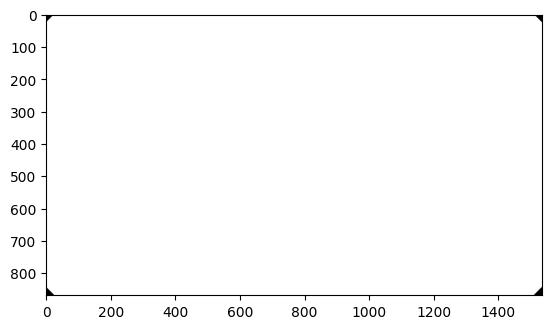

In [ ]:
import cv2
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
from scipy.ndimage import label
import matplotlib.pylab as plt
from skimage.filters import threshold_local
data = Image.open('cute.gif').convert('L')
s= [[0, 1, 0], [1, 1, 1], [0, 1, 0]]
b = nd.binary_opening (data, structure=s, iterations=25)
c = Image.fromarray(b)
c.show ()
plt.imshow(c)
plt.show ()


#### 2.3.3 Sử dụng binary_erosion

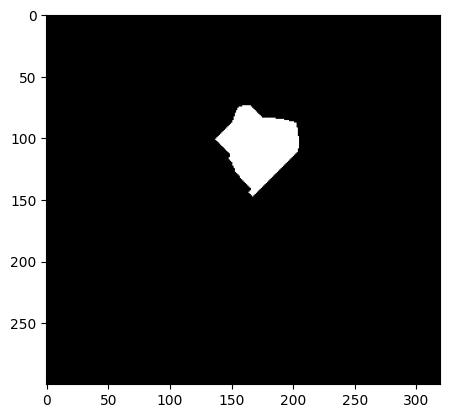

In [ ]:
import cv2
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
from scipy.ndimage import label
import matplotlib.pylab as plt
from skimage.filters import threshold_local
data = Image.open('dil_img.gif').convert('L')
s = [[0, 1, 0], [1, 1, 1], [0, 1, 0]]
b = nd.binary_erosion(data, structure=s, iterations=50)
c = Image.fromarray (b)
c.show()
plt.imshow (c)
plt.show ()



#### 2.3.4 Sử dụng binary_closing

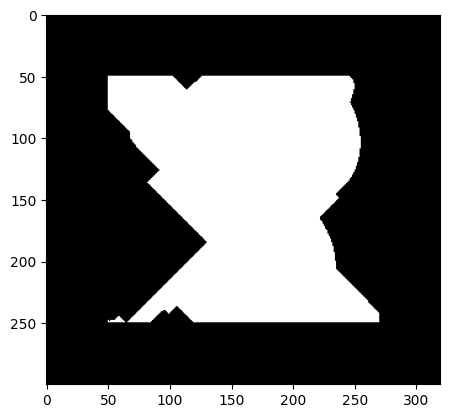

In [ ]:
import cv2
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as np
from scipy.ndimage import label
import matplotlib.pylab as plt
from skimage.filters import threshold_local
data = Image.open('dil_img.gif').convert('L')
s= [[0, 1, 0], [1, 1, 1], [0, 1, 0]]
b= nd.binary_closing (data, structure=s, iterations=50)
c= Image.fromarray (b)
c.show ()
plt.imshow(c)
plt.show ()


## 2. Bài tập

### Bài 1

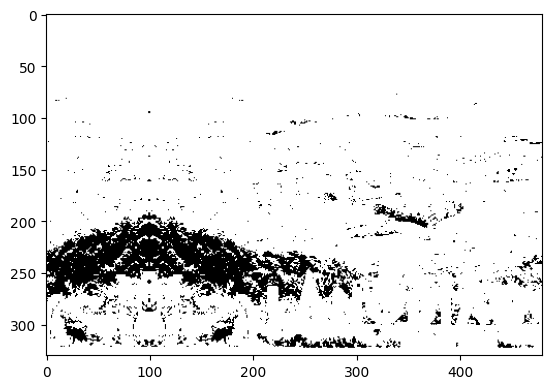

In [28]:
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
import matplotlib.pylab as plt
from skimage.filters.thresholding import threshold_otsu
data = Image.open('exercise/dalat.jpg').convert('L')
a = np.asarray(data)
bmg = a[20:350, 20:500]
bmg = nd.shift(bmg, (0, 100), mode='reflect')
b = (bmg / 255.0) > 0.3
b = Image.fromarray((b * 255).astype(np.uint8))
iio.imsave('lang_biang.jpg', np.array(b))
plt.imshow(b, cmap='gray')
plt.show()


### Bài 2

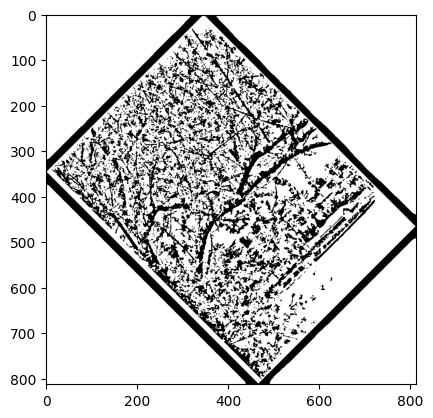

In [ ]:
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
import matplotlib.pylab as plt
from skimage.filters.thresholding import threshold_local
data = Image.open('exercise/dalat.jpg').convert('L')
a = np.asarray(data)
bmg = a[20:680, 500:990]
d1 = nd.rotate(bmg, 45)
b = threshold_local(d1, 61, offset=10)
c = d1 > b  
c_img = (c * 255).astype(np.uint8)
iio.imsave('ho_xuan_huong.jpg', c_img)
plt.imshow(c_img, cmap='gray')
plt.show()


### Bài 3

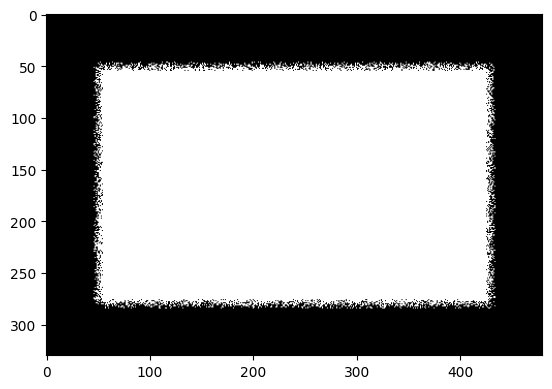

In [47]:
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
import matplotlib.pylab as plt
from skimage.filters.thresholding import threshold_local
data = Image.open('exercise/dalat.jpg').convert('L')
a = np.asarray(data)
bmg = a[20:350, 1000:1480]
c = bmg > 100
s = [[0, 1, 0], [1, 1, 1], [0, 1, 0]]
b = nd.binary_closing(c, structure=s, iterations=50)
result = (b * 255).astype(np.uint8)
H, W = result.shape
Y, X = np.indices((H, W))
d = 5
q = 2 * d * np.random.rand(2, H, W) - d
mp = (np.array([Y, X]) + q).astype(int)
mp[0] = np.clip(mp[0], 0, H - 1)
mp[1] = np.clip(mp[1], 0, W - 1)
distorted = nd.map_coordinates(result, mp, order=1)
Image.fromarray(distorted).show()
iio.imsave('quan_truong_lam_vien.jpg', distorted.astype(np.uint8))
plt.imshow(distorted, cmap='gray')
plt.show()



### Bài 4

=== MENU ===
Geometric transformation:
 1. coordinate_mapping
 2. Rotate
 3. Scale
 4. Shift
Segment:
 5. Adaptive_thresholding
 6. Binary_dilation
 7. Binary_erosion
 8. Otsu
Bạn có thể nhập:
- Một số: 1 đến 8
- Hai số cách nhau: [Geometric] [Segment] (ví dụ: 2 6)


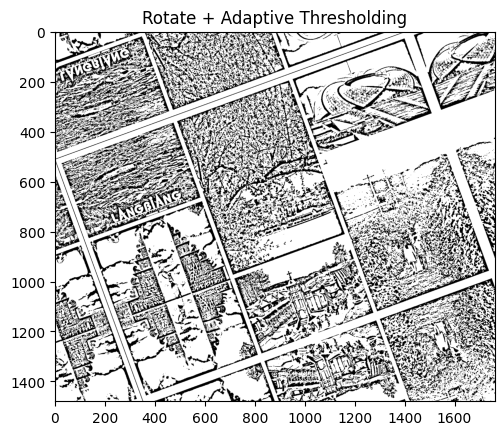

In [ ]:
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
import matplotlib.pyplot as plt
from skimage.filters import threshold_otsu, threshold_local
data = Image.open('exercise/dalat.jpg').convert('L')
a = np.asarray(data)
def coordinate_mapping(img):
    H, W = img.shape
    Y, X = np.indices((H, W))
    d = int(input("Nhập độ biến dạng d: "))
    q = 2 * d * np.random.rand(2, H, W) - d
    mp = (np.array([Y, X]) + q).astype(int)
    mp[0] = np.clip(mp[0], 0, H - 1)
    mp[1] = np.clip(mp[1], 0, W - 1)
    return nd.map_coordinates(img, mp, order=1)
def rotate(img):
    angle = float(input("Nhập góc xoay: "))
    return nd.rotate(img, angle, reshape=True, mode='reflect')
def scale(img):
    factor = float(input("Nhập hệ số scale: "))
    return nd.zoom(img, factor)
def shift(img):
    dx = int(input("Nhập dx: "))
    dy = int(input("Nhập dy: "))
    return nd.shift(img, shift=(dy, dx), mode='reflect')
def adaptive_thresholding(img):
    block_size = int(input("Nhập block size (số lẻ): "))
    if block_size % 2 == 0:
        block_size += 1 
    offset = float(input("Nhập offset: "))
    thres = threshold_local(img, block_size, offset=offset)
    binary = img > thres
    return (binary * 255).astype(np.uint8)
def binary_dilation(img):
    binary = img > 100
    iter = int(input("Nhập số lần lặp dilation: "))
    dilated = nd.binary_dilation(binary, iterations=iter)
    return (dilated * 255).astype(np.uint8)
def binary_erosion(img):
    binary = img > 100
    iter = int(input("Nhập số lần lặp erosion: "))
    eroded = nd.binary_erosion(binary, iterations=iter)
    return (eroded * 255).astype(np.uint8)
def otsu(img):
    thres = threshold_otsu(img)
    binary = img > thres
    return (binary * 255).astype(np.uint8)
print("=== MENU ===")
print("Geometric transformation:")
print(" 1. coordinate_mapping")
print(" 2. Rotate")
print(" 3. Scale")
print(" 4. Shift")
print("Segment:")
print(" 5. Adaptive_thresholding")
print(" 6. Binary_dilation")
print(" 7. Binary_erosion")
print(" 8. Otsu")
print("Bạn có thể nhập:")
print("- Một số: 1 đến 8")
print("- Hai số cách nhau: [Geometric] [Segment] (ví dụ: 2 6)")
choice = input("Nhập lựa chọn: ").strip().split()
output = a.copy()
title_text = ""
if len(choice) == 1:
    c = int(choice[0])
    if c == 1:
        output = coordinate_mapping(output)
        title_text = "Coordinate Mapping"
    elif c == 2:
        output = rotate(output)
        title_text = "Rotate"
    elif c == 3:
        output = scale(output)
        title_text = "Scale"
    elif c == 4:
        output = shift(output)
        title_text = "Shift"
    elif c == 5:
        output = adaptive_thresholding(output)
        title_text = "Adaptive Thresholding"
    elif c == 6:
        output = binary_dilation(output)
        title_text = "Binary Dilation"
    elif c == 7:
        output = binary_erosion(output)
        title_text = "Binary Erosion"
    elif c == 8:
        output = otsu(output)
        title_text = "Otsu"
    else:
        exit()

elif len(choice) == 2:
    g = int(choice[0])
    s = int(choice[1])

    if g == 1:
        output = coordinate_mapping(output)
        title_text = "Coordinate Mapping + "
    elif g == 2:
        output = rotate(output)
        title_text = "Rotate + "
    elif g == 3:
        output = scale(output)
        title_text = "Scale + "
    elif g == 4:
        output = shift(output)
        title_text = "Shift + "
    else:
        exit()

    if s == 5:
        output = adaptive_thresholding(output)
        title_text += "Adaptive Thresholding"
    elif s == 6:
        output = binary_dilation(output)
        title_text += "Binary Dilation"
    elif s == 7:
        output = binary_erosion(output)
        title_text += "Binary Erosion"
    elif s == 8:
        output = otsu(output)
        title_text += "Otsu"
    else:
        exit()
plt.imshow(output, cmap='gray')
plt.title(title_text)
plt.show()


